Minimal full radiation-stress wave setup solver.

Physics steps (cross-shore, offshore → onshore):
  1. Solve dispersion relation for wavenumber k
  2. Compute group velocity cg
  3. Shoal waves conserving energy flux  E·cg = const
  4. Apply breaking  H = γ(h + η̄)  where exceeded
  5. Compute full radiation stress  Sxx = E(2n - 1/2)
  6. Integrate momentum balance  dη̄ = -dSxx / ρg(h + η̄)

h array convention: index 0 = offshore (deepest), index -1 = onshore.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

G     = 9.81
RHO   = 1025.0
GAMMA = 0.5

# ── Step 1: wavenumber ────────────────────────────────────────────────────────
def solve_wavenumber(omega, h):
    """Solve w^2 = gk*tanh(kh) for k via Newton-Raphson. Vectorised."""
    h = np.maximum(h, 0.01)
    k = np.full(np.broadcast_shapes(np.shape(omega), np.shape(h)),
                omega**2 / G)
    for _ in range(25):
        kh  = k * h
        th  = np.tanh(np.minimum(kh, 500.0))
        f   = G * k * th - omega**2
        df  = G * (th + kh * (1 - th**2))
        k  -= f / df
    return np.abs(k)

# ── Step 2: group velocity ────────────────────────────────────────────────────
def group_velocity(k, h):
    r"""cg = n*c, where n = 0.5*(1 + 2kh/sinh(2kh)), c = sqrt(g*tanh(kh)/k)"""
    kh = np.minimum(k * np.maximum(h, 0.01), 500.0)
    n  = 0.5 * (1.0 + 2.0 * kh / np.sinh(2.0 * kh))
    c  = np.sqrt(G * np.tanh(kh) / np.maximum(k, 1e-8))
    return n * c

# ── Step 5: radiation stress (oblique) ────────────────────────────────────────
def radiation_stress(E, k, h, cos_theta=1.0):
    """Sxx = E [ n (1 + cos^2 theta) - 1/2 ]."""
    kh = np.minimum(k * np.maximum(h, 0.01), 500.0)
    n  = 0.5 * (1.0 + 2.0 * kh / np.sinh(2.0 * kh))
    return E * (n * (1.0 + cos_theta**2) - 0.5)

# ── Main solver with oblique incidence ────────────────────────────────────────
def compute_setup_1d(h, H0, T, theta_deg=0.0):
    """
    Full radiation-stress setup with oblique incidence via Snell's law.
    Only the shore-normal component E*cg*cos(theta) of the energy flux
    is conserved; Snell's law evolves theta as c changes.
    theta_deg : incidence angle at h[0] relative to shore normal [deg].
    """
    nx    = len(h)
    omega = 2 * np.pi / T
    h_    = np.maximum(h, 0.01)

    k  = solve_wavenumber(omega, h_)
    cg = group_velocity(k, h_)

    c         = omega / np.maximum(k, 1e-8)
    theta0    = np.deg2rad(theta_deg)
    sin_theta = np.clip(np.sin(theta0) * c / max(c[0], 1e-8), -1.0, 1.0)
    cos_theta = np.sqrt(1.0 - sin_theta**2)

    E0 = 0.125 * RHO * G * H0**2

    eta = np.zeros(nx)
    E   = np.zeros(nx)

    E[0]     = E0
    Sxx_prev = radiation_stress(E[0], k[0], h_[0], cos_theta[0])

    flux_ref = E0 * cg[0] * cos_theta[0]
    broken   = False

    for i in range(1, nx):
        denom   = max(cg[i] * cos_theta[i], 1e-6)
        E_shoal = flux_ref / denom
        H_shoal = np.sqrt(8 * E_shoal / (RHO * G))

        total_depth = max(h[i] + eta[i - 1], 0.01)

        if H_shoal > GAMMA * total_depth:
            E[i] = 0.125 * RHO * G * (GAMMA * total_depth) ** 2
            broken = True
        else:
            E[i] = E_shoal
            if broken:
                flux_ref = E[i] * cg[i] * cos_theta[i]
                broken   = False

        Sxx_curr = radiation_stress(E[i], k[i], h_[i], cos_theta[i])
        d_prev   = max(h[i - 1] + eta[i - 1], 0.01)
        eta[i]   = eta[i - 1] - (Sxx_curr - Sxx_prev) / (RHO * G * d_prev)
        Sxx_prev = Sxx_curr

    H = np.sqrt(8 * E / (RHO * G))
    return eta, H

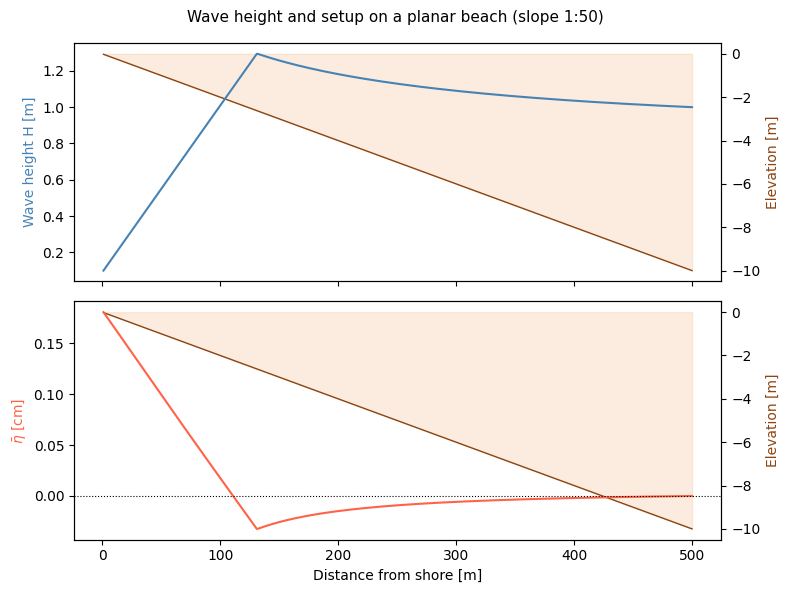

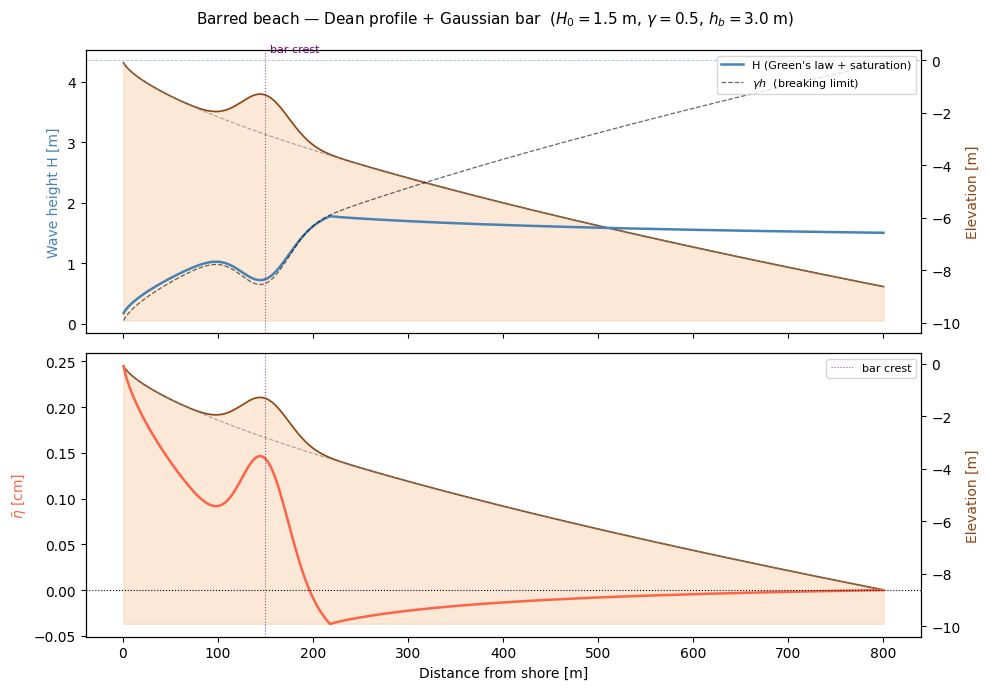

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# 1.  Planar beach — bathy on each panel as background
# ─────────────────────────────────────────────────────────────────────────────

slope = 1.0 / 50.0
x_planar = np.linspace(1.0, 500.0, 500)
h_planar = slope * x_planar

h_in = h_planar[::-1]
eta_p, H_p = compute_setup_1d(h_in, H0=1.0, T=10.0, theta_deg=0.0)
eta_p = eta_p[::-1]
H_p   = H_p[::-1]

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))
fig.suptitle('Wave height and setup on a planar beach (slope 1:50)', fontsize=11)

# Panel 1: wave height + bathy
ax1.plot(x_planar, H_p, color='steelblue', linewidth=1.5, label='H')
ax1.set_ylabel('Wave height H [m]', color='steelblue')
ax1b = ax1.twinx()
ax1b.fill_between(x_planar, -h_planar, 0, color='sandybrown', alpha=0.2)
ax1b.plot(x_planar, -h_planar, color='saddlebrown', linewidth=1.0, label='seabed')
ax1b.set_ylabel('Elevation [m]', color='saddlebrown')
ax1.set_zorder(ax1b.get_zorder() + 1)
ax1.patch.set_visible(False)

# Panel 2: setup + bathy
ax2.plot(x_planar, eta_p, color='tomato', linewidth=1.5, label=r'$\bar{\eta}$')
ax2.axhline(0, color='k', linewidth=0.8, linestyle=':')
ax2.set_ylabel(r'$\bar{\eta}$ [cm]', color='tomato')
ax2.set_xlabel('Distance from shore [m]')
ax2b = ax2.twinx()
ax2b.fill_between(x_planar, -h_planar, 0, color='sandybrown', alpha=0.2)
ax2b.plot(x_planar, -h_planar, color='saddlebrown', linewidth=1.0)
ax2b.set_ylabel('Elevation [m]', color='saddlebrown')
ax2.set_zorder(ax2b.get_zorder() + 1)
ax2.patch.set_visible(False)

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 2.  Barred beach — Dean equilibrium profile + Gaussian bar
# ─────────────────────────────────────────────────────────────────────────────

x = np.linspace(1.0, 800.0, 1000)
A = 0.10
h_dean = A * x ** (2.0 / 3.0)

x_bar, bar_h, bar_sigma = 150.0, 1.5, 25.0
bar   = bar_h * np.exp(-0.5 * ((x - x_bar) / bar_sigma) ** 2)
h_bar = np.maximum(h_dean - bar, 0.05)

h_in           = h_bar[::-1]
eta_raw, H_raw = compute_setup_1d(h_in, H0=1.5, T=10.0, theta_deg=0.0)
eta_bar = eta_raw[::-1]
H_bar   = H_raw[::-1]

h_b = 1.5 / GAMMA

# Trough: landward side of bar crest where barred profile diverges from Dean
i_crest = np.argmin(h_bar)
diffs = np.abs(h_bar[:i_crest] - h_dean[:i_crest])
candidates = np.where(diffs < 0.05)[0]
i_trough_end = candidates[-1] if len(candidates) > 0 else 0

# ── Figure ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 7))
fig.suptitle(
    fr'Barred beach — Dean profile + Gaussian bar  '
    fr'($H_0=1.5$ m, $\gamma={GAMMA}$, $h_b={h_b:.1f}$ m)',
    fontsize=11,
)

# Panel 1: wave height + bathy
ax = axes[0]
ax.plot(x, H_bar, color='steelblue', linewidth=1.8,
        label="H (Green's law + saturation)")
ax.plot(x, GAMMA * h_bar, color='k', linewidth=0.9, linestyle='--',
        alpha=0.6, label=r'$\gamma h$  (breaking limit)')
ax.axvline(x_bar, color='purple', linewidth=0.8, linestyle=':', alpha=0.7)
ax.set_ylabel('Wave height H [m]', color='steelblue')
ax.legend(fontsize=8, loc='upper right')

axb = ax.twinx()
axb.fill_between(x, -h_bar, -np.max(h_bar) * 1.15, color='sandybrown', alpha=0.25)
axb.plot(x, -h_bar,  color='saddlebrown', linewidth=1.2)
axb.plot(x, -h_dean, color='grey', linewidth=0.8, linestyle='--', alpha=0.7)
axb.axhline(0, color='steelblue', linewidth=0.6, linestyle='--', alpha=0.5)
axb.set_ylabel('Elevation [m]', color='saddlebrown')
ax.set_zorder(axb.get_zorder() + 1)
ax.patch.set_visible(False)
axb.text(x_bar + 5, 0.3, 'bar crest', color='purple', fontsize=8)


# Panel 2: setup + bathy
ax = axes[1]
ax.plot(x, eta_bar, color='tomato', linewidth=1.8)
ax.axhline(0, color='k', linewidth=0.8, linestyle=':')
ax.axvline(x_bar, color='purple', linewidth=0.8, linestyle=':', alpha=0.7,
           label='bar crest')
if i_trough_end < i_crest:
    ax.axvspan(x[i_trough_end], x[i_crest], alpha=0.12, color='grey',
               label='trough (formula less reliable)')
ax.set_ylabel(r'$\bar{\eta}$ [cm]', color='tomato')
ax.set_xlabel('Distance from shore [m]')
ax.legend(fontsize=8)

axb = ax.twinx()
axb.fill_between(x, -h_bar, -np.max(h_bar) * 1.15, color='sandybrown', alpha=0.25)
axb.plot(x, -h_bar, color='saddlebrown', linewidth=1.2)
axb.plot(x, -h_dean, color='grey', linewidth=0.8, linestyle='--', alpha=0.7)
axb.set_ylabel('Elevation [m]', color='saddlebrown')
ax.set_zorder(axb.get_zorder() + 1)
ax.patch.set_visible(False)

axb.set_ylim()
plt.tight_layout()
plt.show()

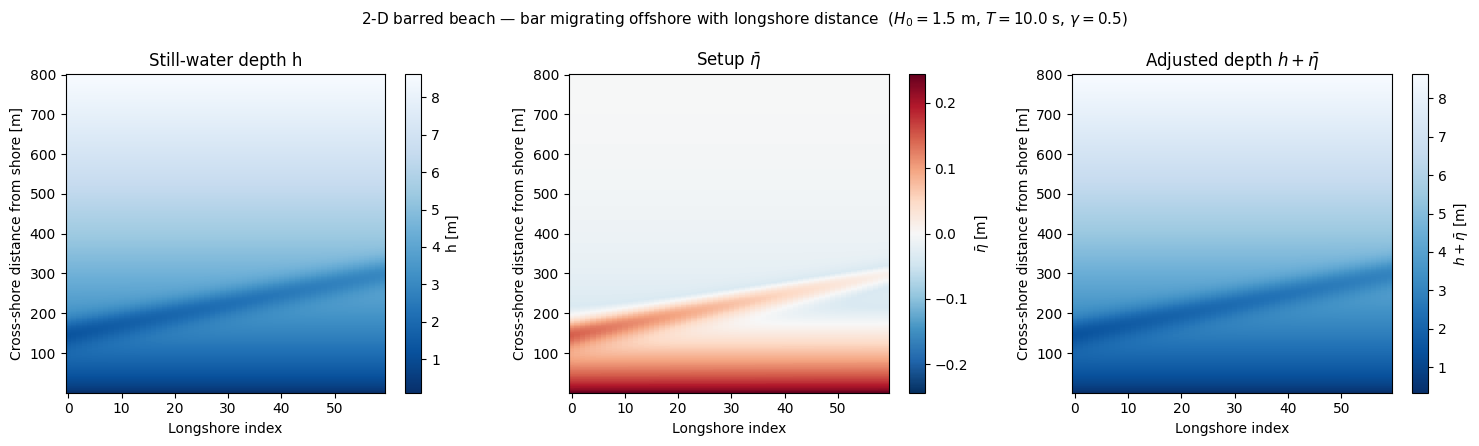

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# 3.  Simple 2-D example — bar migrating offshore with longshore distance
#
# Bathymetry: Dean equilibrium profile + Gaussian bar whose crest position
# shifts linearly offshore as longshore index y increases.  This mimics an
# oblique bar or a gradual longshore change in bar position.
#
# For each longshore column j, compute_setup_1d() is run on the cross-shore
# profile, producing a 2-D setup field η̄(x, y).
# ─────────────────────────────────────────────────────────────────────────────

H0, T = 1.5, 10.0

# Cross-shore grid (offshore → onshore, index 0 = offshore)
nx, ny = 500, 60
x = np.linspace(800.0, 1.0, nx)   # offshore first

# Dean profile
A = 0.10
h_dean = A * x ** (2.0 / 3.0)

# Longshore coordinate (arbitrary units)
y = np.arange(ny, dtype=float)

# Bar crest moves from x=150 m (y=0) to x=300 m (y=ny-1)
x_bar_min, x_bar_max = 150.0, 300.0
x_bar_y = x_bar_min + (x_bar_max - x_bar_min) * y / (ny - 1)   # shape (ny,)

bar_h, bar_sigma = 1.5, 25.0

# Build 2-D depth array h[ix, iy]
x2d   = x[:, np.newaxis]                        # (nx, 1)
xb2d  = x_bar_y[np.newaxis, :]                  # (1, ny)
bar2d = bar_h * np.exp(-0.5 * ((x2d - xb2d) / bar_sigma) ** 2)
h2d   = np.maximum(h_dean[:, np.newaxis] - bar2d, 0.05)   # (nx, ny)

# ── Solve setup for each longshore column ────────────────────────────────────
eta2d = np.zeros((nx, ny))
for j in range(ny):
    eta_1d, _ = compute_setup_1d(h2d[:, j], H0, T, theta_deg=0.0)
    eta2d[:, j] = eta_1d

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle(
    fr'2-D barred beach — bar migrating offshore with longshore distance  '
    fr'($H_0={H0}$ m, $T={T}$ s, $\gamma={GAMMA}$)',
    fontsize=11,
)

# Flip x so shore is on the left in the plot
x_plot = x[::-1]
h_plot   = h2d[::-1, :]
eta_plot = eta2d[::-1, :]

kw = {'shading': 'auto'}

im0 = axes[0].pcolormesh(y, x_plot, h_plot, cmap='Blues_r', **kw)
fig.colorbar(im0, ax=axes[0], label='h [m]')
axes[0].set_title('Still-water depth h')
axes[0].set_xlabel('Longshore index')
axes[0].set_ylabel('Cross-shore distance from shore [m]')

vmax = np.abs(eta_plot).max()
im1 = axes[1].pcolormesh(y, x_plot, eta_plot, cmap='RdBu_r',
                          vmin=-vmax, vmax=vmax, **kw)
fig.colorbar(im1, ax=axes[1], label=r'$\bar{\eta}$ [m]')
axes[1].set_title(r'Setup $\bar{\eta}$')
axes[1].set_xlabel('Longshore index')
axes[1].set_ylabel('Cross-shore distance from shore [m]')

im2 = axes[2].pcolormesh(y, x_plot, h_plot + eta_plot, cmap='Blues_r', **kw)
fig.colorbar(im2, ax=axes[2], label=r'$h + \bar{\eta}$ [m]')
axes[2].set_title(r'Adjusted depth $h + \bar{\eta}$')
axes[2].set_xlabel('Longshore index')
axes[2].set_ylabel('Cross-shore distance from shore [m]')



plt.tight_layout()
plt.show()


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.  Same 2-D example using compute_setup_1_5d
#     Bar follows a mild parabolic trajectory centred at longshore index y = 30
# ─────────────────────────────────────────────────────────────────────────────
from matplotlib.colors import SymLogNorm

from utils.setup_1d import compute_setup_1_5d

H0, T = 1.5, 10.0

nx, ny = 500, 60
x = np.linspace(800.0, 1.0, nx)   # offshore first

A = 0.10
h_dean = A * x ** (2.0 / 3.0)

y = np.arange(ny, dtype=float)

# Parabolic bar: crest closest to shore at y=30, drifts offshore on either side
y_center    = 30.0
x_bar_apex  = 300.0   # bar crest cross-shore position at y=30 [m from shore]
x_bar_flank = 100.0   # extra offshore shift at the longshore edges [m]
x_bar_y = x_bar_apex + x_bar_flank * ((y - y_center) / y_center) ** 2

bar_h, bar_sigma = 1.5, 25.0

x2d   = x[:, np.newaxis]                         # (nx, 1)
xb2d  = x_bar_y[np.newaxis, :]                   # (1, ny)
bar2d = bar_h * np.exp(-0.5 * ((x2d - xb2d) / bar_sigma) ** 2)
h2d   = np.maximum(h_dean[:, np.newaxis] - bar2d, 0.05)   # (nx, ny)

# ── Reshape for compute_setup_1_5d: (time, n_along, n_cross) ─────────────────
# h2d[:, j] is offshore→onshore; flip so index 0 is onshore, then transpose
h_15d = h2d[::-1, :].T[np.newaxis, :, :]         # (1, ny, nx)
# E = rho*g*m0, with m0 = integral S(f) df from the wave energy density spectrum
import xarray as xr

ds = xr.load_dataset('../combined_dunex_dataset_lerp.nc')
RHO_W = 1025.0
E0    = (RHO_W * G * ds.waveEnergyDensity.integrate('waveFrequency')).values
Tp    = np.array([T])

eta_out = compute_setup_1_5d(E0, Tp, h_15d)   # shore-normal (default)      # (1, ny, nx), onshore first

# Restore to (nx, ny) with offshore first to match h2d for plotting
eta2d = eta_out[0].T[::-1]                        # (nx, ny)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle(
    fr'2-D barred beach (1.5-D solver) — parabolic bar centred at $y=30$  '
    fr'($H_0={H0}$ m, $T={T}$ s, $\gamma={GAMMA}$)',
    fontsize=11,
)

x_plot   = x[::-1]          # shore→offshore for y-axis
h_plot   = h2d[::-1, :]
eta_plot = eta2d[::-1, :]

kw = {'shading': 'auto'}

im0 = axes[0].pcolormesh(y, x_plot, h_plot, cmap='Blues_r', **kw)
fig.colorbar(im0, ax=axes[0], label='h [m]')
axes[0].set_title('Still-water depth h')

vmax = np.abs(eta_plot).max()
im1 = axes[1].pcolormesh(y, x_plot, eta_plot, cmap='RdBu_r',
                          vmin=-vmax, vmax=vmax, **kw)
fig.colorbar(im1, ax=axes[1], label=r'$\bar{\eta}$ [m]')
axes[1].set_title(r'Setup $\bar{\eta}$')

im2 = axes[2].pcolormesh(
    y, x_plot, eta_plot / h_plot,
    cmap='RdBu_r', 
    norm=SymLogNorm(linthresh=1e-1),
    **kw,
)
fig.colorbar(im2, ax=axes[2], label=r'$h + \bar{\eta}$ [m]')
axes[2].set_title(r'Setup $\bar{\eta}$ / depth $h$')

for ax in axes:
    ax.plot(y, x_bar_y, 'w--', linewidth=1.2, alpha=0.8, label='bar crest')
    ax.set_xlabel('Longshore index')
    ax.legend(fontsize=8, loc='upper right')

axes[0].set_ylabel('Cross-shore distance from shore [m]')

plt.tight_layout()
plt.show()


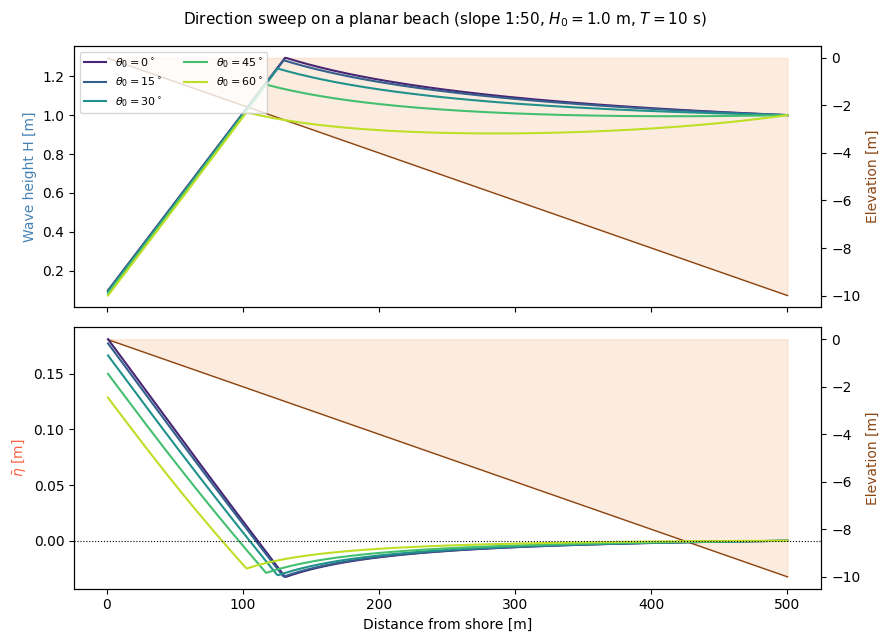

In [6]:
# -----------------------------------------------------------------------------
# 5.  Direction sweep on a planar beach
#
# Vary the offshore incidence angle theta_0 relative to shore normal from
# 0 deg (shore-normal) to 60 deg (strongly oblique). Only the shore-normal
# component E*cg*cos(theta) of the energy flux drives setup, so obliquity
# systematically reduces wave height and setup as |theta_0| grows. Snell's
# law refracts the waves toward shore-normal as depth decreases.
# -----------------------------------------------------------------------------

slope    = 1.0 / 50.0
x_planar = np.linspace(1.0, 500.0, 500)
h_planar = slope * x_planar
h_in     = h_planar[::-1]   # offshore first

thetas = np.array([0.0, 15.0, 30.0, 45.0, 60.0])
cmap   = plt.cm.viridis
colors = cmap(np.linspace(0.1, 0.9, len(thetas)))

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(9, 6.5))
fig.suptitle(
    r'Direction sweep on a planar beach (slope 1:50, $H_0=1.0$ m, $T=10$ s)',
    fontsize=11,
)

for theta, col in zip(thetas, colors):
    eta_t, H_t = compute_setup_1d(h_in, H0=1.0, T=10.0, theta_deg=theta)
    eta_t = eta_t[::-1]
    H_t   = H_t[::-1]
    lbl   = fr'$\theta_0={theta:.0f}^\circ$'
    ax1.plot(x_planar, H_t,   color=col, linewidth=1.5, label=lbl)
    ax2.plot(x_planar, eta_t, color=col, linewidth=1.5, label=lbl)

# Bathy on twin axes
for ax in (ax1, ax2):
    axb = ax.twinx()
    axb.fill_between(x_planar, -h_planar, 0, color='sandybrown', alpha=0.2)
    axb.plot(x_planar, -h_planar, color='saddlebrown', linewidth=1.0)
    axb.set_ylabel('Elevation [m]', color='saddlebrown')
    ax.set_zorder(axb.get_zorder() + 1)
    ax.patch.set_visible(False)

ax1.set_ylabel('Wave height H [m]', color='steelblue')
ax1.legend(fontsize=8, loc='upper left', ncol=2)
ax2.axhline(0, color='k', linewidth=0.8, linestyle=':')
ax2.set_ylabel(r'$\bar{\eta}$ [m]', color='tomato')
ax2.set_xlabel('Distance from shore [m]')

plt.tight_layout()
plt.show()
